# Imports

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector

In [3]:
import warnings
warnings.filterwarnings("ignore")   

# Checking Data

In [4]:
df = pd.read_csv("D:\Sales_performance_analyzer\data\spain_sales_raw.csv")

In [5]:
print(df.head())

   order_id  order_date customer_id     customer_name     product  \
0  ES-00001  2025-03-27   CUST-0013  Víctor Domínguez      Tablet   
1  ES-00002  2025-04-18   CUST-0084      Mario Moreno  Smartphone   
2  ES-00003  2025-10-03   CUST-0062     Daniel Méndez       Mouse   
3  ES-00004  2025-12-18   CUST-0082   Alejandro Vidal  Smartphone   
4  ES-00005  2025-02-07   CUST-0075     Pablo Pascual  Smartphone   

      category  quantity  unit_price     region     salesperson  
0  Electronics         8      735.79     Madrid    Pablo García  
1  Electronics         3     1061.26    Navarre  Beatriz Martín  
2  Accessories         5       79.66    Navarre    Pablo García  
3  Electronics         1      731.19     Murcia  Alejandro Ruiz  
4  Electronics         1     1082.93  Andalusia    Clara Molina  


In [6]:
df.isnull().sum()

order_id         0
order_date       0
customer_id      0
customer_name    0
product          0
category         0
quantity         0
unit_price       0
region           0
salesperson      0
dtype: int64

# Analysis

In [7]:
df["revenue"] = df["quantity"] * df["unit_price"]

On the flow of money

In [8]:
# Total revenue
print("Total revenue ",df["revenue"].sum())
print("")

# Revenue by month
df["order_date"] = pd.to_datetime(df["order_date"])
x1 = df.groupby(df["order_date"].dt.to_period("M"))["revenue"].sum()
print("Revenue by month :\n",x1)

Total revenue  382480.41

Revenue by month :
 order_date
2025-01    16244.55
2025-02    44744.88
2025-03    28109.33
2025-04    31835.02
2025-05    22718.49
2025-06    31646.78
2025-07    18983.09
2025-08    41499.59
2025-09    49270.73
2025-10    35791.85
2025-11    31202.28
2025-12    30433.82
Freq: M, Name: revenue, dtype: float64


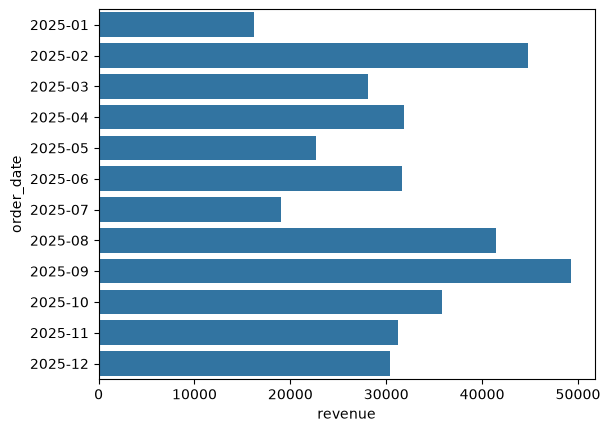

In [13]:
x1 = x1.reset_index()
sns.barplot(data=x1,y="order_date",x="revenue")
plt.show()

In [15]:
# Revenue by region
y1 = df.groupby("region")["revenue"].sum()
print("Revenue by region: \n",y1)

Revenue by region: 
 region
Andalusia            27361.39
Aragon               22318.76
Asturias              6513.58
Balearic Islands     27606.20
Basque Country       25076.82
Canary Islands       31313.58
Cantabria            59103.74
Castile and León     27920.64
Castile-La Mancha    19247.58
Catalonia            10753.72
Extremadura          11414.79
Galicia               6268.79
La Rioja             14960.33
Madrid               26556.16
Murcia               28293.69
Navarre              20403.03
Valencia             17367.61
Name: revenue, dtype: float64


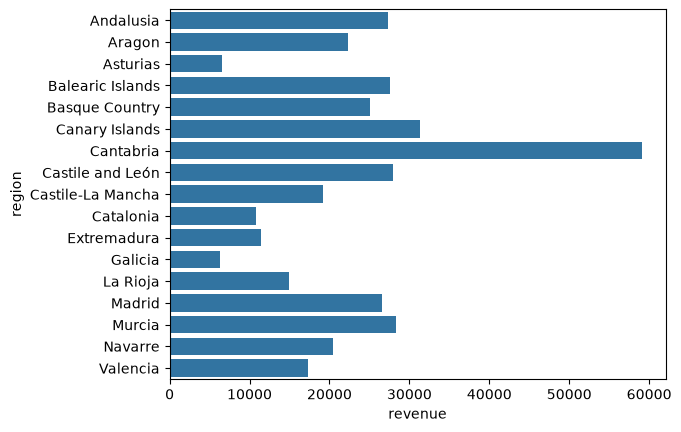

In [16]:
y1 = y1.reset_index()
sns.barplot(data=y1,y="region",x="revenue")
plt.show()

In [28]:
# Expenditure by Customers
z = df.groupby("customer_name")["revenue"].sum()
print("Expenditure by person: \n",z)

Expenditure by person: 
 customer_name
Adrián Campos     1876.32
Adrián García     1897.23
Adrián López      4482.88
Adrián Pascual    5035.47
Adrián Vega       6327.66
                   ...   
Ángel Romero      6242.39
Óscar Díaz         666.95
Óscar Moreno      2881.17
Óscar Pascual     2057.03
Óscar Sanz         448.09
Name: revenue, Length: 100, dtype: float64


On Products/Categories

In [32]:
# Categories bought the most and the amount spend on them
a = df.groupby("category")['category'].count()
print(a)

print("")

aa = df.groupby("category")['revenue'].sum()
print(aa)

category
Accessories    139
Electronics    207
Office          93
Stationery      61
Name: category, dtype: int64

category
Accessories     25948.58
Electronics    294048.16
Office          60506.53
Stationery       1977.14
Name: revenue, dtype: float64


In [36]:
# Most popular category each month
ab = (
    df.groupby([df["order_date"].dt.to_period("M"), "category"])
      .size()
      .reset_index(name="count")
)

ab = ab.sort_values(
    ["order_date", "count"],
    ascending=[True, False]
)

top_category = ab.groupby("order_date").head(1)

print(top_category)

   order_date     category  count
1     2025-01  Electronics     11
5     2025-02  Electronics     24
9     2025-03  Electronics     18
13    2025-04  Electronics     18
17    2025-05  Electronics     16
21    2025-06  Electronics     19
25    2025-07  Electronics     16
29    2025-08  Electronics     19
33    2025-09  Electronics     19
37    2025-10  Electronics     16
41    2025-11  Electronics     15
44    2025-12  Accessories     17


In [33]:
# Product sold the most and amount spend on them
b = df.groupby("product")["product"].count()
print(b)

print("")

ba = df.groupby("product")["revenue"].sum()
print(ba)

product
Backpack        34
Desk            30
Desk Lamp       32
External SSD    36
Headphones      34
Keyboard        39
Laptop          22
Monitor         24
Mouse           36
Notebook        29
Pen Set         32
Printer         31
Smartphone      26
Tablet          32
USB-C Hub       30
Webcam          33
Name: product, dtype: int64

product
Backpack          5871.03
Desk             32888.58
Desk Lamp         4050.98
External SSD     17747.95
Headphones       13906.53
Keyboard          9302.82
Laptop          108342.45
Monitor          21685.32
Mouse             4906.09
Notebook           842.60
Pen Set           1134.54
Printer          23566.97
Smartphone       54940.10
Tablet           68156.83
USB-C Hub         5868.64
Webcam            9268.98
Name: revenue, dtype: float64


In [60]:
# Most product category  each month
bb = df.groupby([df["order_date"].dt.to_period("M"),"product"]).size().reset_index(name="count")
bb = bb.sort_values(["order_date","count"],ascending=[True,False])

top_prod = bb.groupby("order_date").head(1)

print(top_prod)

    order_date       product  count
5      2025-01      Keyboard      5
25     2025-02       Pen Set      5
45     2025-03        Webcam      5
53     2025-04         Mouse      5
61     2025-05      Backpack      5
79     2025-06  External SSD      4
95     2025-07  External SSD      5
108    2025-08          Desk      5
128    2025-09      Keyboard      7
152    2025-10     USB-C Hub      5
157    2025-11  External SSD      5
174    2025-12         Mouse      7


On Sales person

In [ ]:
# Sales Person vs their earnings
c = df.groupby("salesperson")["revenue"].sum()
print(c)

salesperson
Alejandro Ruiz     24019.29
Beatriz Martín     35872.08
Carlos Navarro     25723.64
Clara Molina       47219.37
Diana Sánchez      21419.06
Eduardo Gómez      21664.38
Elena Ramos        37614.21
Javier Ortega      36969.07
Laura Fernández    31975.02
Miguel Torres      26060.29
Pablo García       33729.32
Sofía Romero       40214.68
Name: revenue, dtype: float64


In [ ]:
# Sales person vs their selling in different regions
ca = df.groupby(["salesperson", "region"])["revenue"].sum()
print(ca)

salesperson     region          
Alejandro Ruiz  Andalusia           1978.40
                Aragon              4474.31
                Asturias             390.51
                Balearic Islands    2137.53
                Basque Country       593.12
                                     ...   
Sofía Romero    Galicia              916.22
                Madrid              2321.70
                Murcia              4744.75
                Navarre             2989.20
                Valencia            2143.80
Name: revenue, Length: 182, dtype: float64
